# Chunking Strategies Lab

This notebook compares three chunking strategies for retrieval:

- **Fixed chunking**
- **Semantic chunking**
- **Structure-aware chunking**

## What we will do
1. Load one JSON dataset
2. Convert each document into text
3. Show how the same document looks under:
   - fixed chunking
   - semantic chunking
   - structure-aware chunking
4. Tune **fixed chunk size only**
5. Save the best fixed result
6. Compare it against:
   - semantic chunking
   - structure-aware chunking
7. Inspect final retrieval quality

## Important note
Change `JSON_PATH` below to whichever domain file you want to use.

In [98]:
# Uncomment only if needed
!pip install -q chromadb sentence-transformers pandas matplotlib scikit-learn

In [99]:
# Basic imports
import json
import re
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import chromadb

## 1. Configuration

In [100]:
JSON_PATH = "/kaggle/input/datasets/sakharam/multidomaindocqa/chunking_lab_merged_all_domains_v1.json"   # change this
TOP_K = 5
FIXED_CHUNK_SIZES = [64, 128, 192]

# This embedding model is small and easy to use for a teaching lab
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Chroma path
CHROMA_DIR = "./chroma_lab_simple"

# Semantic chunking setting
SEMANTIC_SIMILARITY_THRESHOLD = 0.5

## 2. Load the dataset

The JSON files contain:
- `documents`
- `queries`

Each query also contains gold fields like:
- `gold_doc_id`
- `gold_section_heading`
- `gold_answer_text`

We will load **all queries** and ignore validation/test splits for now.

In [101]:
with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

documents = data["documents"]
queries = data["queries"]

print("Documents:", len(documents))
print("Queries:", len(queries))
print("First document keys:", documents[0].keys())
print("First query keys:", queries[0].keys())

Documents: 66
Queries: 330
First document keys: dict_keys(['doc_id', 'title', 'domain', 'sections', 'source_dataset'])
First query keys: dict_keys(['query_id', 'query_text', 'query_type', 'split', 'gold_doc_id', 'gold_section_id', 'gold_section_heading', 'gold_answer_text', 'source_dataset'])


## 3. Turn a document into plain text

Some datasets store documents as sections.
This helper converts each document into one readable text string.

It is written to handle common section styles:
- `paragraphs`
- `content`
- `text`

In [102]:
def document_to_text(doc):
    parts = []

    # Title
    if "title" in doc and doc["title"]:
        parts.append(doc["title"])

    # Sections
    for sec in doc.get("sections", []):
        heading = sec.get("heading") or sec.get("section_heading") or ""
        if heading:
            parts.append(f"## {heading}")

        if "paragraphs" in sec and sec["paragraphs"]:
            for p in sec["paragraphs"]:
                parts.append(str(p))

        elif "content" in sec and sec["content"]:
            if isinstance(sec["content"], list):
                for x in sec["content"]:
                    parts.append(str(x))
            else:
                parts.append(str(sec["content"]))

        elif "text" in sec and sec["text"]:
            parts.append(str(sec["text"]))

    return "\n\n".join(parts)

In [103]:
# Quick sanity check
example_doc = documents[0]
example_text = document_to_text(example_doc)

print("Doc ID:", example_doc["doc_id"])
print("Title:", example_doc.get("title", ""))
print()
print(example_text[:1200])

Doc ID: aircraft_domain__aircraft_flight_ops
Title: Commercial Aircraft Flight Operations Guide

Commercial Aircraft Flight Operations Guide

## Preflight Preparation

Before a flight begins, the crew reviews the flight release, fuel planning summary, weather package, notices to air missions, and aircraft technical log. The purpose of this review is not only to confirm that the route is legal and practical, but also to identify any operational constraints that could affect departure, cruise, or arrival. Dispatch information, maintenance remarks, and performance assumptions must be read together so that the crew has a consistent picture of the flight.

During preflight preparation, pilots also verify the minimum equipment assumptions used in planning, expected runway conditions, and alternate airport strategy. A short delay on the ground may be preferable to departing with unclear information about weather, runway contamination, or aircraft status. Effective preflight preparation reduce

## 4. Simple sentence splitting

In [104]:
def split_into_sentences(text):
    text = re.sub(r"\s+", " ", text).strip()
    if not text:
        return []
    return [s.strip() for s in re.split(r'(?<=[.!?])\s+', text) if s.strip()]

## 5. Fixed chunking (no overlap)

This is the simplest chunker.
It just takes `chunk_size` words at a time.

In [105]:
def fixed_chunk_document(doc, chunk_size):
    text = document_to_text(doc)
    words = text.split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk_text = " ".join(words[i:i+chunk_size])
        chunks.append({
            "chunk_id": f"{doc['doc_id']}_fixed_{len(chunks)}",
            "doc_id": doc["doc_id"],
            "title": doc.get("title", ""),
            "section": "UNKNOWN_OR_MIXED",
            "strategy": "fixed",
            "chunk_index": len(chunks),
            "text": chunk_text,
            "token_count": len(chunk_text.split()),
        })

    return chunks

## 6. Semantic chunking

Simple idea:
- split into sentences
- compare neighboring sentences
- start a new chunk when the topic seems to shift
- also stop when the chunk gets too large

In [106]:
embed_model = SentenceTransformer(EMBED_MODEL_NAME)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [107]:
def semantic_chunk_document(doc, max_chunk_size, similarity_threshold=0.65):
    text = document_to_text(doc)
    sentences = split_into_sentences(text)

    if not sentences:
        return []

    sent_embs = embed_model.encode(sentences, show_progress_bar=False)

    chunks = []
    current = [sentences[0]]

    for i in range(1, len(sentences)):
        prev_emb = sent_embs[i-1].reshape(1, -1)
        curr_emb = sent_embs[i].reshape(1, -1)
        sim = cosine_similarity(prev_emb, curr_emb)[0][0]

        tentative = " ".join(current + [sentences[i]])
        tentative_len = len(tentative.split())

        if sim < similarity_threshold or tentative_len > max_chunk_size:
            chunks.append(" ".join(current))
            current = [sentences[i]]
        else:
            current.append(sentences[i])

    if current:
        chunks.append(" ".join(current))

    output = []
    for idx, chunk_text in enumerate(chunks):
        output.append({
            "chunk_id": f"{doc['doc_id']}_semantic_{idx}",
            "doc_id": doc["doc_id"],
            "title": doc.get("title", ""),
            "section": "SEMANTIC_GROUP",
            "strategy": "semantic",
            "chunk_index": idx,
            "text": chunk_text,
            "token_count": len(chunk_text.split()),
        })

    return output

## 7. Structure-aware chunking

This chunker follows the document's own sections.
If a section is too long, it splits only **inside that section**.

In [108]:
def structure_chunk_document(doc, max_chunk_size):
    chunks = []
    idx = 0

    for sec in doc.get("sections", []):
        heading = sec.get("heading") or sec.get("section_heading") or ""

        # collect section text
        section_parts = []

        if "paragraphs" in sec and sec["paragraphs"]:
            section_parts.extend([str(p) for p in sec["paragraphs"]])

        elif "content" in sec and sec["content"]:
            if isinstance(sec["content"], list):
                section_parts.extend([str(x) for x in sec["content"]])
            else:
                section_parts.append(str(sec["content"]))

        elif "text" in sec and sec["text"]:
            section_parts.append(str(sec["text"]))

        section_text = " ".join(section_parts).strip()
        if not section_text:
            continue

        words = section_text.split()

        # if short enough, keep as one chunk
        if len(words) <= max_chunk_size:
            pieces = [section_text]
        else:
            pieces = []
            for i in range(0, len(words), max_chunk_size):
                pieces.append(" ".join(words[i:i+max_chunk_size]))

        for piece in pieces:
            chunks.append({
                "chunk_id": f"{doc['doc_id']}_structure_{idx}",
                "doc_id": doc["doc_id"],
                "title": doc.get("title", ""),
                "section": heading,
                "strategy": "structure",
                "chunk_index": idx,
                "text": piece,
                "token_count": len(piece.split()),
            })
            idx += 1

    return chunks

## 8. Show how the three chunkers look on the same document

In [109]:
def show_chunks(chunks, n=3, max_chars=400):
    for c in chunks[:n]:
        print("=" * 80)
        print("strategy   :", c["strategy"])
        print("doc_id     :", c["doc_id"])
        print("section    :", c["section"])
        print("chunk_index:", c["chunk_index"])
        print("tokens     :", c["token_count"])
        print("-" * 80)
        print(c["text"][:max_chars] + ("..." if len(c["text"]) > max_chars else ""))
        print()

fixed_example = fixed_chunk_document(example_doc, chunk_size=64)
semantic_example = semantic_chunk_document(example_doc, max_chunk_size=128, similarity_threshold=SEMANTIC_SIMILARITY_THRESHOLD)
structure_example = structure_chunk_document(example_doc, max_chunk_size=128)

print("FIXED CHUNKS")
show_chunks(fixed_example, n=3)

print("SEMANTIC CHUNKS")
show_chunks(semantic_example, n=3)

print("STRUCTURE-AWARE CHUNKS")
show_chunks(structure_example, n=3)

FIXED CHUNKS
strategy   : fixed
doc_id     : aircraft_domain__aircraft_flight_ops
section    : UNKNOWN_OR_MIXED
chunk_index: 0
tokens     : 64
--------------------------------------------------------------------------------
Commercial Aircraft Flight Operations Guide ## Preflight Preparation Before a flight begins, the crew reviews the flight release, fuel planning summary, weather package, notices to air missions, and aircraft technical log. The purpose of this review is not only to confirm that the route is legal and practical, but also to identify any operational constraints that could affect departure, cruise, or...

strategy   : fixed
doc_id     : aircraft_domain__aircraft_flight_ops
section    : UNKNOWN_OR_MIXED
chunk_index: 1
tokens     : 64
--------------------------------------------------------------------------------
maintenance remarks, and performance assumptions must be read together so that the crew has a consistent picture of the flight. During preflight preparation, pi

## 9. Chroma helpers

We will use Chroma to store chunks and retrieve top-k matches.

In [110]:
client = chromadb.PersistentClient(path=CHROMA_DIR)

def build_collection(collection_name, chunks):
    # delete old collection if it exists
    try:
        client.delete_collection(collection_name)
    except:
        pass

    collection = client.create_collection(collection_name)

    texts = [c["text"] for c in chunks]
    embeddings = embed_model.encode(texts, show_progress_bar=False)

    collection.add(
        ids=[c["chunk_id"] for c in chunks],
        documents=texts,
        embeddings=embeddings.tolist(),
        metadatas=[
            {
                "doc_id": c["doc_id"],
                "title": c["title"],
                "section": c["section"],
                "strategy": c["strategy"],
                "chunk_index": c["chunk_index"],
                "token_count": c["token_count"],
            }
            for c in chunks
        ]
    )
    return collection

In [111]:
def retrieve_topk(collection, query_text, top_k=5):
    query_emb = embed_model.encode([query_text], show_progress_bar=False)[0]

    results = collection.query(
        query_embeddings=[query_emb.tolist()],
        n_results=top_k
    )
    return results

## 10. Simple evaluation

A retrieved chunk is counted as relevant if:
- its `doc_id` matches the gold document
- and either:
  - its section matches the gold section heading, or
  - the gold answer text appears inside the chunk

This is simple and easy for students to understand.

In [112]:
def is_relevant(doc_text, meta, query):
    same_doc = meta["doc_id"] == query["gold_doc_id"]
    same_section = meta["section"] == query.get("gold_section_heading", "")
    answer_in_text = query["gold_answer_text"].lower() in doc_text.lower()
    return same_doc and (same_section or answer_in_text)

def evaluate_collection(collection, query_list, top_k=5):
    rows = []

    for q in query_list:
        results = retrieve_topk(collection, q["query_text"], top_k=top_k)

        docs = results["documents"][0]
        metas = results["metadatas"][0]

        relevant_ranks = []
        for rank, (doc_text, meta) in enumerate(zip(docs, metas), start=1):
            if is_relevant(doc_text, meta, q):
                relevant_ranks.append(rank)

        row = {
            "query_id": q["query_id"],
            "query_text": q["query_text"],
            "recall@1": 1.0 if any(r <= 1 for r in relevant_ranks) else 0.0,
            "recall@3": 1.0 if any(r <= 3 for r in relevant_ranks) else 0.0,
            "recall@5": 1.0 if any(r <= 5 for r in relevant_ranks) else 0.0,
            "mrr@5": (1.0 / min(relevant_ranks)) if relevant_ranks else 0.0,
        }
        rows.append(row)

    return pd.DataFrame(rows)

## 11. Tune fixed chunk size only

We skip overlap completely in this lab.

This keeps the experiment faster and easier to understand.

In [113]:
fixed_results = []

for chunk_size in FIXED_CHUNK_SIZES:
    all_chunks = []
    for doc in documents:
        all_chunks.extend(fixed_chunk_document(doc, chunk_size=chunk_size))

    collection_name = f"fixed_{chunk_size}"
    collection = build_collection(collection_name, all_chunks)

    eval_df = evaluate_collection(collection, queries, top_k=TOP_K)

    fixed_results.append({
        "strategy": "fixed",
        "chunk_size": chunk_size,
        "recall@1": eval_df["recall@1"].mean(),
        "recall@3": eval_df["recall@3"].mean(),
        "recall@5": eval_df["recall@5"].mean(),
        "mrr@5": eval_df["mrr@5"].mean(),
        "num_chunks": len(all_chunks),
    })

fixed_results_df = pd.DataFrame(fixed_results)
fixed_results_df = fixed_results_df.sort_values(["recall@5", "mrr@5"], ascending=[False, False])
fixed_results_df

,strategy,chunk_size,recall@1,recall@3,recall@5,mrr@5,num_chunks
2,fixed,192,0.718182,0.857576,0.872727,0.784646,176
1,fixed,128,0.690909,0.796970,0.818182,0.743939,251
0,fixed,64,0.578788,0.696970,0.706061,0.634949,472


## 12. Plot fixed chunk size results

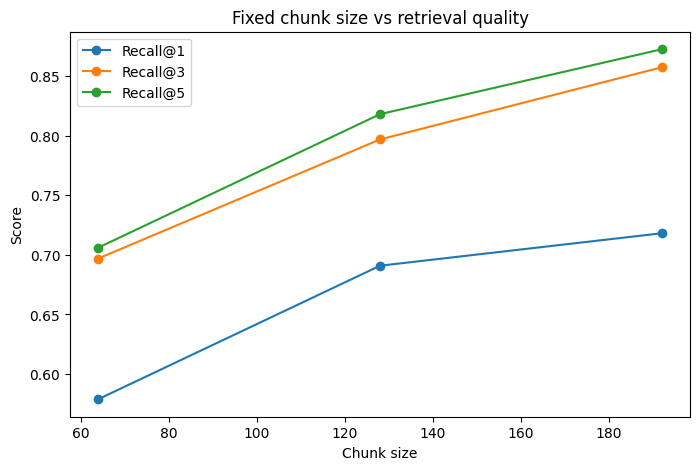

In [114]:
plt.figure(figsize=(8, 5))
plt.plot(fixed_results_df["chunk_size"], fixed_results_df["recall@1"], marker="o", label="Recall@1")
plt.plot(fixed_results_df["chunk_size"], fixed_results_df["recall@3"], marker="o", label="Recall@3")
plt.plot(fixed_results_df["chunk_size"], fixed_results_df["recall@5"], marker="o", label="Recall@5")
plt.xlabel("Chunk size")
plt.ylabel("Score")
plt.title("Fixed chunk size vs retrieval quality")
plt.legend()
plt.show()

## 13. Pick the best fixed chunk size

In [115]:
best_fixed_chunk_size = int(fixed_results_df.iloc[0]["chunk_size"])
print("Best fixed chunk size:", best_fixed_chunk_size)

Best fixed chunk size: 192


## 14. Evaluate semantic chunking

For fairness, we use the **best fixed chunk size** as the maximum chunk cap.

In [116]:
semantic_chunks = []
for doc in documents:
    semantic_chunks.extend(
        semantic_chunk_document(
            doc,
            max_chunk_size=best_fixed_chunk_size,
            similarity_threshold=SEMANTIC_SIMILARITY_THRESHOLD
        )
    )

semantic_collection = build_collection("semantic", semantic_chunks)
semantic_eval_df = evaluate_collection(semantic_collection, queries, top_k=TOP_K)

semantic_summary = {
    "strategy": "semantic",
    "chunk_size": best_fixed_chunk_size,
    "recall@1": semantic_eval_df["recall@1"].mean(),
    "recall@3": semantic_eval_df["recall@3"].mean(),
    "recall@5": semantic_eval_df["recall@5"].mean(),
    "mrr@5": semantic_eval_df["mrr@5"].mean(),
    "num_chunks": len(semantic_chunks),
}
semantic_summary

{'strategy': 'semantic',
 'chunk_size': 192,
 'recall@1': np.float64(0.603030303030303),
 'recall@3': np.float64(0.7545454545454545),
 'recall@5': np.float64(0.8212121212121212),
 'mrr@5': np.float64(0.687020202020202),
 'num_chunks': 1279}

## 15. Evaluate structure-aware chunking

For fairness, we use the same maximum chunk cap where section splitting is needed.

In [117]:
structure_chunks = []
for doc in documents:
    structure_chunks.extend(
        structure_chunk_document(doc, max_chunk_size=best_fixed_chunk_size)
    )

structure_collection = build_collection("structure", structure_chunks)
structure_eval_df = evaluate_collection(structure_collection, queries, top_k=TOP_K)

structure_summary = {
    "strategy": "structure",
    "chunk_size": best_fixed_chunk_size,
    "recall@1": structure_eval_df["recall@1"].mean(),
    "recall@3": structure_eval_df["recall@3"].mean(),
    "recall@5": structure_eval_df["recall@5"].mean(),
    "mrr@5": structure_eval_df["mrr@5"].mean(),
    "num_chunks": len(structure_chunks),
}
structure_summary

{'strategy': 'structure',
 'chunk_size': 192,
 'recall@1': np.float64(0.9393939393939394),
 'recall@3': np.float64(1.0),
 'recall@5': np.float64(1.0),
 'mrr@5': np.float64(0.9686868686868686),
 'num_chunks': 354}

## 16. Final comparison table

In [118]:
best_fixed_summary = fixed_results_df.iloc[0].to_dict()

final_results_df = pd.DataFrame([
    best_fixed_summary,
    semantic_summary,
    structure_summary,
])

final_results_df

,strategy,chunk_size,recall@1,recall@3,recall@5,mrr@5,num_chunks
0,fixed,192,0.718182,0.857576,0.872727,0.784646,176
1,semantic,192,0.603030,0.754545,0.821212,0.687020,1279
2,structure,192,0.939394,1.000000,1.000000,0.968687,354


## 17. Show a retrieval example

This is useful in class because students can see what each strategy actually returns.

In [119]:
def show_retrieval_examples(query, top_k=3):
    collections = {
        "fixed_best": build_collection(
            f"fixed_best_{best_fixed_chunk_size}",
            [chunk for doc in documents for chunk in fixed_chunk_document(doc, best_fixed_chunk_size)]
        ),
        "semantic": semantic_collection,
        "structure": structure_collection,
    }

    print("=" * 100)
    print("QUERY:", query["query_text"])
    print("GOLD DOC:", query["gold_doc_id"])
    print("GOLD SECTION:", query.get("gold_section_heading", ""))
    print("=" * 100)

    for name, collection in collections.items():
        print("\n###", name.upper())
        results = retrieve_topk(collection, query["query_text"], top_k=top_k)

        docs = results["documents"][0]
        metas = results["metadatas"][0]

        for rank, (doc_text, meta) in enumerate(zip(docs, metas), start=1):
            print("-" * 80)
            print("rank   :", rank)
            print("doc_id :", meta["doc_id"])
            print("section:", meta["section"])
            print(doc_text[:300] + ("..." if len(doc_text) > 300 else ""))
            print()

show_retrieval_examples(queries[5], top_k=3)

QUERY: What drives the scheduling of routine maintenance tasks?
GOLD DOC: aircraft_domain__aircraft_maintenance_planning
GOLD SECTION: Scheduled Maintenance Philosophy

### FIXED_BEST
--------------------------------------------------------------------------------
rank   : 1
doc_id : aircraft_domain__aircraft_maintenance_planning
section: UNKNOWN_OR_MIXED
Aircraft Maintenance Planning Handbook ## Scheduled Maintenance Philosophy Scheduled maintenance is organized around time, cycles, flight hours, or calendar intervals depending on the system and the manufacturer’s maintenance planning document. The purpose of scheduled work is to inspect, service, o...

--------------------------------------------------------------------------------
rank   : 2
doc_id : aircraft_domain__aircraft_maintenance_planning
section: UNKNOWN_OR_MIXED
Because time is limited, line maintenance depends on accurate defect descriptions and good coordination among maintenance control, station technicians, and operati